# Practical No. 03: Autoencoder and Variational Autoencoder for Image Reconstruction

**Name:** Parth Kitchloo  
**PRN:** 202401110014  
**Batch:** A2  
**Branch:** AIML  

### Aim
To build an **Autoencoder (AE)** and a **Variational Autoencoder (VAE)** for image reconstruction and generation using the MNIST dataset, and compare their reconstruction quality and latent-space properties.

### Learning Outcomes
- Understand encoder–decoder architecture.
- Implement an Autoencoder for image reconstruction.
- Implement a VAE using mean, log-variance and reparameterization.
- Understand reconstruction loss and KL-divergence.
- Generate new images from the VAE latent space.
- Compare AE and VAE results.

### Dataset
**MNIST handwritten digit dataset** — 60,000 training images and 10,000 test images, each of size 28×28 grayscale.

Dataset documentation: https://keras.io/api/datasets/mnist/

> **Submission tip:** Run all cells before submission so that every graph, reconstructed image, generated image, and result is visible in the notebook.


### Training Configuration
Both models are trained for **20 epochs** to give the networks enough time to learn useful image representations while keeping the notebook practical to run in Google Colab.


In [1]:
# Cell 1: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility: results will be reasonably consistent between runs.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")


TensorFlow version: 2.20.0
Libraries imported successfully.


In [2]:
# Cell 2: Load and preprocess the MNIST dataset
# MNIST images are 28x28 grayscale. Pixel values are converted from 0-255 to 0-1.

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add a channel dimension: (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)
print("Pixel range    :", x_train.min(), "to", x_train.max())


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28, 1)
Testing images : (10000, 28, 28, 1)
Pixel range    : 0.0 to 1.0


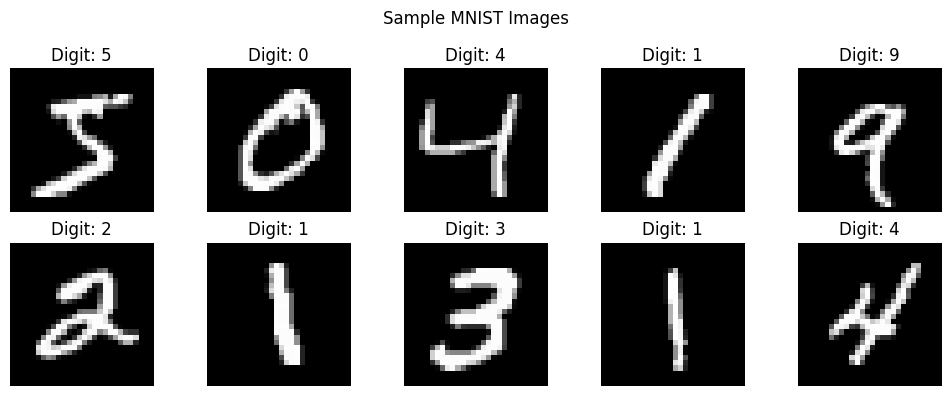

In [3]:
# Cell 3: Visualize sample training images
plt.figure(figsize=(10, 4))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()


## Part A — Autoencoder (AE)

An Autoencoder contains an **encoder** and a **decoder**.

- **Encoder:** converts the input image into a compact latent representation.
- **Latent space:** compressed representation of the important image features.
- **Decoder:** reconstructs the image from the latent representation.

The AE is trained to minimize reconstruction error. Here, **Mean Squared Error (MSE)** is used as the reconstruction loss.


In [4]:
# Cell 4: Build the Autoencoder
# The encoder compresses a 28x28 image into a 16-dimensional latent vector.
# The decoder reconstructs the original image from this vector.

latent_dim = 16

ae_input = keras.Input(shape=(28, 28, 1), name="ae_input")

# Encoder
x = layers.Flatten()(ae_input)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
ae_latent = layers.Dense(latent_dim, name="latent_vector")(x)

# Decoder
x = layers.Dense(64, activation="relu")(ae_latent)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(28 * 28, activation="sigmoid")(x)
ae_output = layers.Reshape((28, 28, 1))(x)

autoencoder = keras.Model(ae_input, ae_output, name="Autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()


Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ae_input (InputLayer)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,320 (860.62 KB)

 Trainable params: 220,320 (860.62 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Cell 5: Train the Autoencoder
# The target is the input itself because an autoencoder learns reconstruction.

EPOCHS_AE = 20  # More epochs for better reconstruction quality
BATCH_SIZE = 128

history_ae = autoencoder.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=EPOCHS_AE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)


Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - loss: 0.0489 - val_loss: 0.0284
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0247 - val_loss: 0.0212
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0201 - val_loss: 0.0186
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0181 - val_loss: 0.0170
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0168 - val_loss: 0.0160
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0159 - val_loss: 0.0153
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0152 - val_loss: 0.0147
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0147 - val_loss: 0.0142
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0143 - val_loss: 0.0138
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0139 - val_loss: 0.0135
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0135 - val_loss: 0.0132
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━

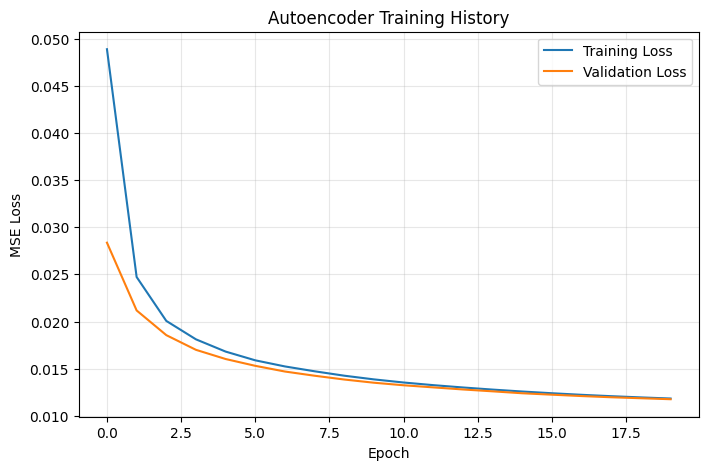

In [6]:
# Cell 6: Plot Autoencoder training and validation loss

plt.figure(figsize=(8, 5))
plt.plot(history_ae.history["loss"], label="Training Loss")
plt.plot(history_ae.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


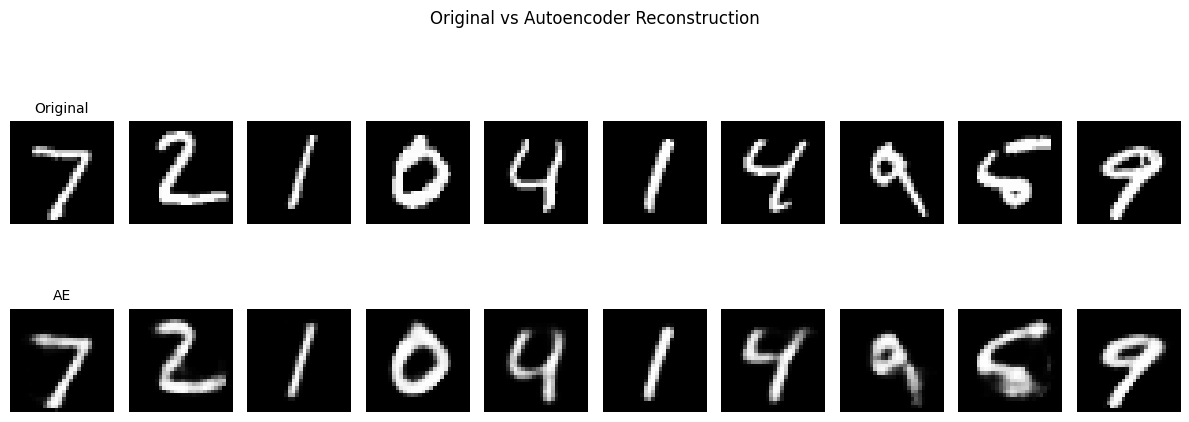

In [7]:
# Cell 7: Compare original and AE reconstructed images

ae_reconstructed = autoencoder.predict(x_test[:10], verbose=0)

plt.figure(figsize=(12, 5))

for i in range(10):
    # Original images
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", fontsize=10)

    # Reconstructed images
    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(ae_reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("AE", fontsize=10)

plt.suptitle("Original vs Autoencoder Reconstruction")
plt.tight_layout()
plt.show()


In [8]:
# Cell 8: Calculate Autoencoder reconstruction MSE

# Reconstruct the complete test set so its shape matches x_test.
# Earlier, only 10 images were reconstructed for visualization.
ae_test_reconstructed = autoencoder.predict(x_test, verbose=0)

# Mean Squared Error (MSE) measures average pixel-wise reconstruction error.
ae_mse = np.mean((x_test - ae_test_reconstructed) ** 2)

print(f"Autoencoder test reconstruction MSE: {ae_mse:.6f}")


Autoencoder test reconstruction MSE: 0.011755


## Part B — Variational Autoencoder (VAE)

A VAE learns a **probability distribution** in latent space instead of mapping every image to one fixed latent vector.

The encoder learns:
- **μ (mean)**
- **log(σ²) (log variance)**

A latent vector is sampled using the **reparameterization trick**:

**z = μ + exp(0.5 × log(σ²)) × ε**, where ε is sampled from a standard normal distribution.

The VAE loss has two components:

1. **Reconstruction loss:** measures how close the reconstructed image is to the original.
2. **KL divergence:** encourages the learned latent distribution to remain close to a standard normal distribution.

Therefore:

**Total VAE Loss = Reconstruction Loss + KL Divergence**


In [9]:
# Cell 9: Build the VAE
# A compact custom VAE keeps the implementation easy to understand and explain in viva.

class VAE(keras.Model):
    def __init__(self, latent_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim

        # Encoder layers
        self.flatten = layers.Flatten()
        self.encoder_dense1 = layers.Dense(128, activation="relu")
        self.encoder_dense2 = layers.Dense(64, activation="relu")
        self.z_mean = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var = layers.Dense(latent_dim, name="z_log_var")

        # Decoder layers
        self.decoder_dense1 = layers.Dense(64, activation="relu")
        self.decoder_dense2 = layers.Dense(128, activation="relu")
        self.decoder_output = layers.Dense(28 * 28, activation="sigmoid")
        self.reshape = layers.Reshape((28, 28, 1))

    def encode(self, x):
        x = self.flatten(x)
        x = self.encoder_dense1(x)
        x = self.encoder_dense2(x)
        return self.z_mean(x), self.z_log_var(x)

    def reparameterize(self, z_mean, z_log_var):
        # Reparameterization trick allows gradient-based training.
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def decode(self, z):
        z = self.decoder_dense1(z)
        z = self.decoder_dense2(z)
        z = self.decoder_output(z)
        return self.reshape(z)

    def call(self, inputs):
        z_mean, z_log_var = self.encode(inputs)
        z = self.reparameterize(z_mean, z_log_var)
        reconstructed = self.decode(z)
        return reconstructed, z_mean, z_log_var


vae = VAE(latent_dim=latent_dim, name="VAE")
optimizer = keras.optimizers.Adam(learning_rate=0.001)

vae.build((None, 28, 28, 1))
vae.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'VAE', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "VAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_mean (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_log_var (Dense)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Cell 10: Train the VAE
# This custom training loop records reconstruction and KL losses separately.

EPOCHS_VAE = 20  # More epochs for better reconstruction and latent-space learning
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
train_dataset = train_dataset.shuffle(10000, seed=SEED).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

vae_total_history = []
vae_recon_history = []
vae_kl_history = []
vae_val_history = []

def compute_vae_loss(model, batch):
    reconstructed, z_mean, z_log_var = model(batch)

    # Reconstruction loss: sum pixel-wise squared error, averaged over batch.
    recon_loss = tf.reduce_mean(
        tf.reduce_sum(tf.square(batch - reconstructed), axis=(1, 2, 3))
    )

    # KL divergence between learned latent distribution and N(0, I).
    kl_loss = tf.reduce_mean(
        -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
    )

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss

for epoch in range(EPOCHS_VAE):
    total_meter = tf.keras.metrics.Mean()
    recon_meter = tf.keras.metrics.Mean()
    kl_meter = tf.keras.metrics.Mean()

    for batch in train_dataset:
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = compute_vae_loss(vae, batch)

        gradients = tape.gradient(total_loss, vae.trainable_weights)
        optimizer.apply_gradients(zip(gradients, vae.trainable_weights))

        total_meter.update_state(total_loss)
        recon_meter.update_state(recon_loss)
        kl_meter.update_state(kl_loss)

    # Validation total loss
    val_meter = tf.keras.metrics.Mean()
    for batch in val_dataset:
        val_loss, _, _ = compute_vae_loss(vae, batch)
        val_meter.update_state(val_loss)

    vae_total_history.append(float(total_meter.result()))
    vae_recon_history.append(float(recon_meter.result()))
    vae_kl_history.append(float(kl_meter.result()))
    vae_val_history.append(float(val_meter.result()))

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_VAE} | "
        f"Loss: {total_meter.result():.2f} | "
        f"Recon: {recon_meter.result():.2f} | "
        f"KL: {kl_meter.result():.2f} | "
        f"Val: {val_meter.result():.2f}"
    )


Epoch 01/20 | Loss: 53.37 | Recon: 50.89 | KL: 2.48 | Val: 43.92
Epoch 02/20 | Loss: 40.72 | Recon: 34.75 | KL: 5.97 | Val: 37.89
Epoch 03/20 | Loss: 36.62 | Recon: 29.08 | KL: 7.54 | Val: 35.13
Epoch 04/20 | Loss: 34.61 | Recon: 26.22 | KL: 8.39 | Val: 33.61
Epoch 05/20 | Loss: 33.31 | Recon: 24.28 | KL: 9.03 | Val: 32.62
Epoch 06/20 | Loss: 32.51 | Recon: 23.06 | KL: 9.45 | Val: 31.95
Epoch 07/20 | Loss: 31.99 | Recon: 22.30 | KL: 9.69 | Val: 31.51
Epoch 08/20 | Loss: 31.59 | Recon: 21.73 | KL: 9.85 | Val: 31.19
Epoch 09/20 | Loss: 31.25 | Recon: 21.27 | KL: 9.98 | Val: 30.80
Epoch 10/20 | Loss: 30.99 | Recon: 20.89 | KL: 10.10 | Val: 30.77
Epoch 11/20 | Loss: 30.79 | Recon: 20.60 | KL: 10.19 | Val: 30.45
Epoch 12/20 | Loss: 30.62 | Recon: 20.33 | KL: 10.29 | Val: 30.23
Epoch 13/20 | Loss: 30.46 | Recon: 20.11 | KL: 10.35 | Val: 30.11
Epoch 14/20 | Loss: 30.33 | Recon: 19.91 | KL: 10.42 | Val: 30.12
Epoch 15/20 | Loss: 30.19 | Recon: 19.73 | KL: 10.46 | Val: 30.12
Epoch 16/20 | Loss:

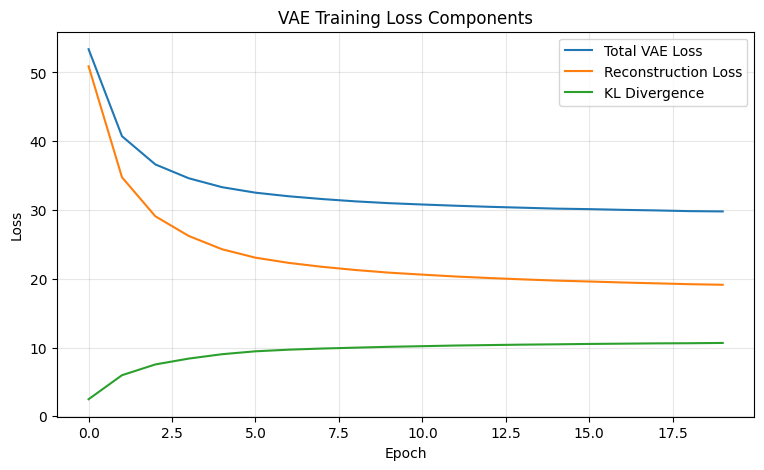

In [11]:
# Cell 11: Plot VAE training losses

plt.figure(figsize=(9, 5))
plt.plot(vae_total_history, label="Total VAE Loss")
plt.plot(vae_recon_history, label="Reconstruction Loss")
plt.plot(vae_kl_history, label="KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Components")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


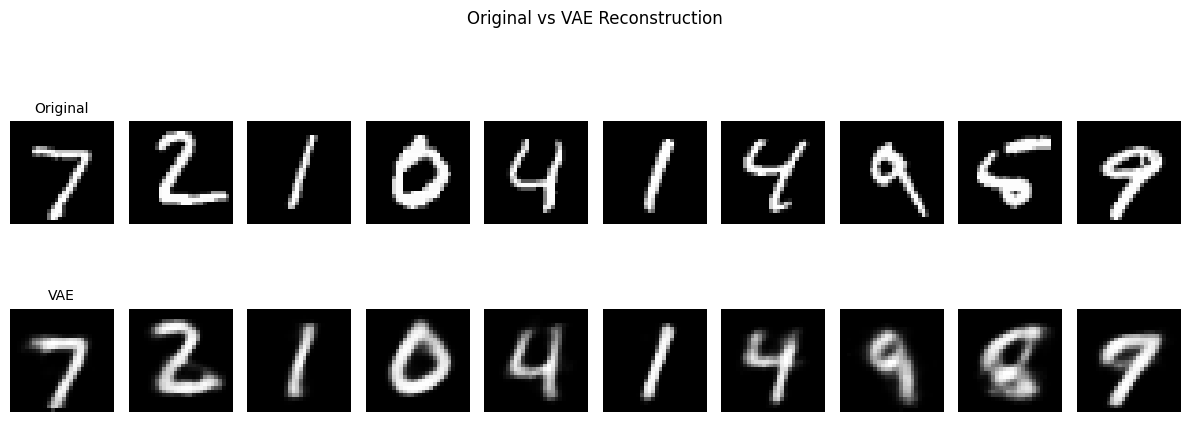

In [12]:
# Cell 12: Compare original and VAE reconstructed images

vae_reconstructed, vae_means, vae_log_vars = vae(x_test[:10])

plt.figure(figsize=(12, 5))

for i in range(10):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", fontsize=10)

    ax = plt.subplot(2, 10, i + 11)
    plt.imshow(vae_reconstructed[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("VAE", fontsize=10)

plt.suptitle("Original vs VAE Reconstruction")
plt.tight_layout()
plt.show()


In [13]:
# Cell 13: Calculate VAE reconstruction MSE

# Use the VAE mean as a stable latent representation for evaluation.
vae_test_reconstructed, _, _ = vae(x_test, training=False)
vae_mse = np.mean(
    (x_test - vae_test_reconstructed.numpy()) ** 2
)

print(f"VAE test reconstruction MSE: {vae_mse:.6f}")


VAE test reconstruction MSE: 0.024111


## Part C — Generate New Images using the VAE

One major advantage of a VAE is that its latent space is regularized toward a standard normal distribution.

Therefore, we can sample random vectors from **N(0, I)** and pass them through the decoder to generate new images.


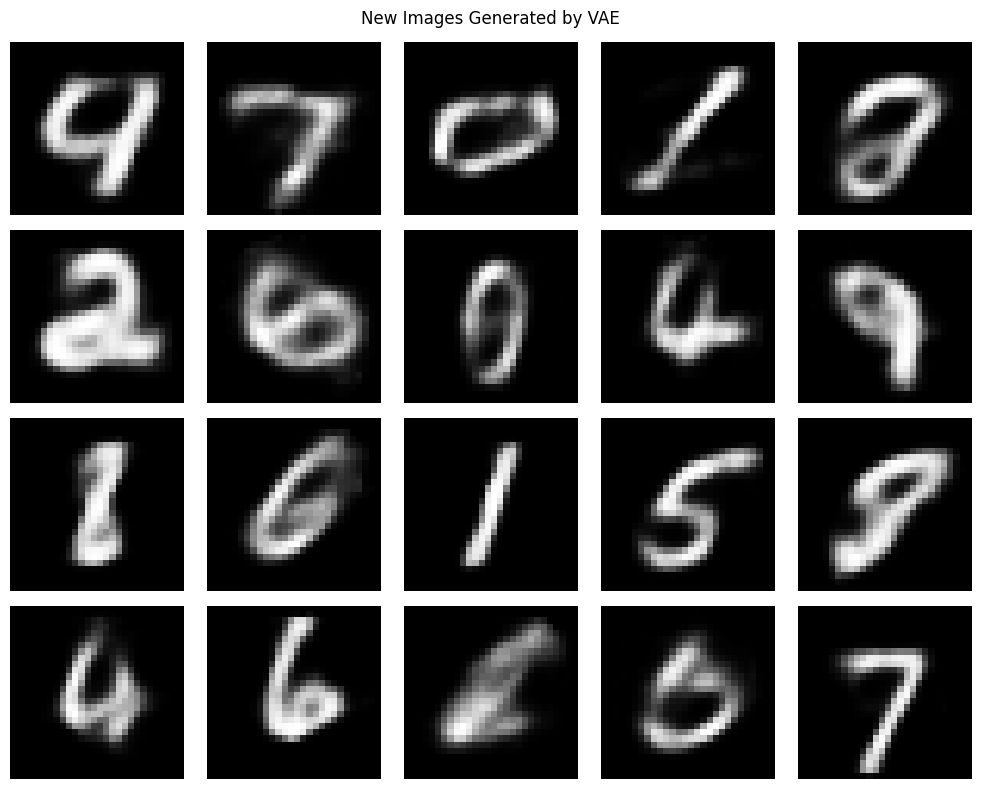

In [14]:
# Cell 14: Generate new images from random latent vectors

num_generated = 20

# Sample latent vectors from a standard normal distribution.
random_latent_vectors = tf.random.normal(
    shape=(num_generated, latent_dim),
    seed=SEED
)

generated_images = vae.decode(random_latent_vectors).numpy()

plt.figure(figsize=(10, 8))

for i in range(num_generated):
    ax = plt.subplot(4, 5, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("New Images Generated by VAE")
plt.tight_layout()
plt.show()


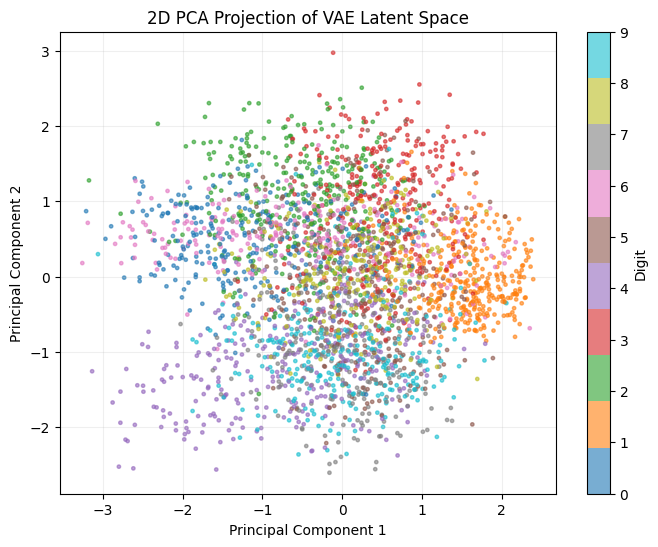

In [15]:
# Cell 15: Visualize the 2D projection of the VAE latent space
# PCA reduces the 16-dimensional latent vectors to 2 dimensions for visualization.

from sklearn.decomposition import PCA

sample_count = 3000
z_mean_all, _ = vae.encode(x_test[:sample_count])

pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_mean_all.numpy())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=y_test[:sample_count],
    cmap="tab10",
    s=6,
    alpha=0.6
)
plt.colorbar(scatter, label="Digit")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of VAE Latent Space")
plt.grid(alpha=0.2)
plt.show()


In [16]:
# Cell 16: Quantitative comparison of AE and VAE

print("========== MODEL COMPARISON ==========")
print(f"Autoencoder MSE : {ae_mse:.6f}")
print(f"VAE MSE         : {vae_mse:.6f}")
print("======================================")

print("\nInterpretation:")
if ae_mse < vae_mse:
    print("The AE has lower reconstruction MSE on this run, indicating lower pixel-wise reconstruction error.")
elif vae_mse < ae_mse:
    print("The VAE has lower reconstruction MSE on this run, indicating lower pixel-wise reconstruction error.")
else:
    print("Both models have approximately the same reconstruction MSE.")

print("Note: MSE alone does not measure every aspect of visual quality.")


========== MODEL COMPARISON ==========
Autoencoder MSE : 0.011755
VAE MSE         : 0.024111

Interpretation:
The AE has lower reconstruction MSE on this run, indicating lower pixel-wise reconstruction error.
Note: MSE alone does not measure every aspect of visual quality.


### Visual Comparison of Reconstruction Error

The following bar chart compares the pixel-wise reconstruction MSE of the Autoencoder and VAE. A lower MSE indicates lower average pixel-wise reconstruction error for this test set.

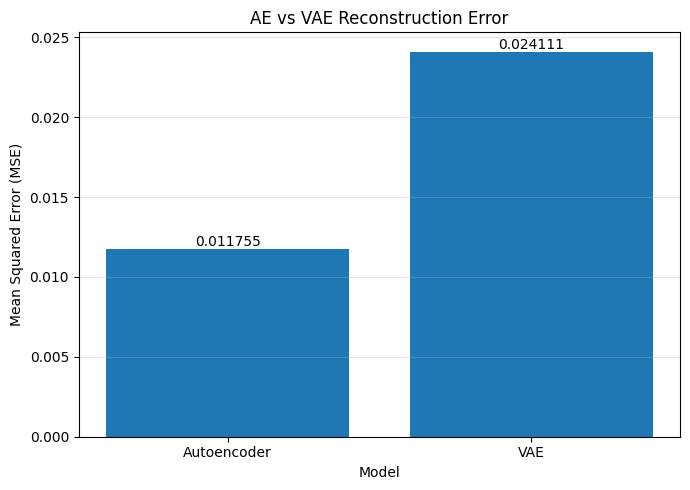

In [17]:
# Cell 17: AE vs VAE reconstruction MSE bar graph

models = ["Autoencoder", "VAE"]
mse_values = [ae_mse, vae_mse]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, mse_values)
plt.ylabel("Mean Squared Error (MSE)")
plt.xlabel("Model")
plt.title("AE vs VAE Reconstruction Error")
plt.grid(axis="y", alpha=0.3)

# Display the exact MSE value above each bar.
for bar, value in zip(bars, mse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.6f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## Output Analysis and Comparison

### 1. Reconstruction
The Autoencoder learns a deterministic compressed representation and reconstructs the input image from that representation. Its reconstructions are generally clear because the model directly minimizes reconstruction error.

The VAE also reconstructs the images, but its latent representation is probabilistic. The KL-divergence term regularizes the latent space, so VAE reconstructions can appear smoother or slightly blurrier than AE reconstructions.

### 2. Image Generation
The standard Autoencoder is primarily designed for reconstruction. Randomly sampling its latent space does not necessarily produce meaningful images because its latent space is not explicitly forced to follow a known distribution.

The VAE is specifically designed to support generation. Since its latent distribution is regularized toward a standard normal distribution, random latent vectors can be decoded into new digit-like images.

### 3. Latent Space
The AE produces a deterministic latent vector for each input. The VAE represents each input using a mean and variance, producing a smoother and more continuous probabilistic latent space.

### 4. Loss Functions
**AE:**  
Reconstruction Loss = MSE

**VAE:**  
Total Loss = Reconstruction Loss + KL Divergence

### 5. Overall Comparison

| Criterion | Autoencoder (AE) | Variational Autoencoder (VAE) |
|---|---|---|
| Encoder | Deterministic | Probabilistic |
| Latent representation | Fixed vector | Mean + variance |
| Reconstruction | Usually sharper | Often smoother |
| Reconstruction loss | MSE | Reconstruction component |
| KL divergence | Not used | Used |
| Random image generation | Not guaranteed | Supported |
| Latent space | Not explicitly regularized | Regularized toward N(0, I) |
| Main application | Compression/reconstruction | Reconstruction + generation |

### Important Observation
A lower MSE means lower pixel-wise reconstruction error, but visual quality and generative quality should also be inspected. The VAE's main advantage is not necessarily the lowest reconstruction error; it is the **structured latent space that enables meaningful sampling and generation**.


## Conclusion

In this practical, an Autoencoder and a Variational Autoencoder were implemented using the MNIST dataset.

The Autoencoder learned to compress images into a latent representation and reconstruct them using a decoder. The VAE extended this concept by learning a probabilistic latent distribution using mean and variance and applying the reparameterization trick.

The experiments demonstrate that the Autoencoder is effective for image reconstruction, while the VAE provides an additional capability of generating new images by sampling from its regularized latent space.

Thus, both models can perform image reconstruction, but the **VAE is more suitable when a structured latent space and image generation are required**.
